In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import optuna

In [4]:
df_train = pd.read_parquet("/Users/tharmmm/Documents/store_sale_project/train_featured.parquet")
df_test = pd.read_parquet("/Users/tharmmm/Documents/store_sale_project/test_featured.parquet")

In [5]:
df_train.head()

,date,store_nbr,family,onpromotion,day_of_week,month,year,week_of_year,is_weekend,is_holiday,...,promo_lag_7,city,state,type,cluster,dcoilwtico,day_of_month,is_month_start,is_month_end,sales
0,2013-01-01,1,AUTOMOTIVE,0,1,1,2013,1,0,1,...,NaN,Quito,Pichincha,D,13,93.14,1,1,0,0.0
1,2013-01-02,1,AUTOMOTIVE,0,2,1,2013,1,0,0,...,NaN,Quito,Pichincha,D,13,93.14,2,0,0,2.0
2,2013-01-03,1,AUTOMOTIVE,0,3,1,2013,1,0,0,...,NaN,Quito,Pichincha,D,13,92.97,3,0,0,3.0
3,2013-01-04,1,AUTOMOTIVE,0,4,1,2013,1,0,0,...,NaN,Quito,Pichincha,D,13,93.12,4,0,0,3.0
4,2013-01-05,1,AUTOMOTIVE,0,5,1,2013,1,1,0,...,NaN,Quito,Pichincha,D,13,93.12,5,0,0,5.0


In [6]:
df_train.columns

Index(['date', 'store_nbr', 'family', 'onpromotion', 'day_of_week', 'month',
       'year', 'week_of_year', 'is_weekend', 'is_holiday', 'is_earthquake',
       'is_other_event', 'is_promo', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14',
       'sales_rolling_mean_28', 'sales_rolling_std_7', 'promo_lag_7', 'city',
       'state', 'type', 'cluster', 'dcoilwtico', 'day_of_month',
       'is_month_start', 'is_month_end', 'sales'],
      dtype='object')

In [7]:
df_test.head()

,store_nbr,family,onpromotion,day_of_week,month,year,week_of_year,is_weekend,day_of_month,is_month_start,...,sales_rolling_mean_7,sales_rolling_mean_14,sales_rolling_mean_28,sales_rolling_std_7,promo_lag_7,city,state,type,cluster,dcoilwtico
0,1,AUTOMOTIVE,0,2.0,8.0,2017.0,33,0.0,16.0,0.0,...,4.142857,4.714286,5.035714,3.287784,0.0,Quito,Pichincha,D,13,46.80
1,1,AUTOMOTIVE,0,3.0,8.0,2017.0,33,0.0,17.0,0.0,...,NaN,NaN,NaN,NaN,0.0,Quito,Pichincha,D,13,47.07
2,1,AUTOMOTIVE,0,4.0,8.0,2017.0,33,0.0,18.0,0.0,...,NaN,NaN,NaN,NaN,0.0,Quito,Pichincha,D,13,48.59
3,1,AUTOMOTIVE,0,5.0,8.0,2017.0,33,1.0,19.0,0.0,...,NaN,NaN,NaN,NaN,0.0,Quito,Pichincha,D,13,48.59
4,1,AUTOMOTIVE,0,6.0,8.0,2017.0,33,1.0,20.0,0.0,...,NaN,NaN,NaN,NaN,0.0,Quito,Pichincha,D,13,48.59


In [8]:
df_test.columns

Index(['store_nbr', 'family', 'onpromotion', 'day_of_week', 'month', 'year',
       'week_of_year', 'is_weekend', 'day_of_month', 'is_month_start',
       'is_month_end', 'is_holiday', 'is_earthquake', 'is_other_event',
       'is_promo', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
       'sales_rolling_mean_7', 'sales_rolling_mean_14',
       'sales_rolling_mean_28', 'sales_rolling_std_7', 'promo_lag_7', 'city',
       'state', 'type', 'cluster', 'dcoilwtico'],
      dtype='object')

In [9]:
len(df_train['date'].unique())

1684

In [10]:
print(df_train["date"].min(), "to", df_train["date"].max())

2013-01-01 00:00:00 to 2017-08-15 00:00:00


Split train and validation set

Train: 2013-01-01 to 2017-07-31 (~4.5 years)
Validation: 2017-08-01 to 2017-08-15 (15 days)
Test: 2017-08-16 to 2017-08-31 (16 days)

In [11]:
val_start = "2017-08-01"

X_train = df_train[df_train["date"] < val_start].drop(columns=["sales", "date"])
y_train = df_train[df_train["date"] < val_start]["sales"]

X_val = df_train[df_train["date"] >= val_start].drop(columns=["sales", "date"])
y_val = df_train[df_train["date"] >= val_start]["sales"]


In [12]:
for col in ["family", "city", "state", "type"]:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")

In [13]:
for col in ["family", "city", "state", "type"]:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    df_test[col] = df_test[col].astype("category")  # add this


Model

In [21]:
# LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    enable_categorical=True,
    early_stopping_rounds=50
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 53703
Early stopping, best iteration is:
[57]	valid_0's l2: 51762.8
[0]	validation_0-rmse:1185.68968
[100]	validation_0-rmse:230.45443
[104]	validation_0-rmse:228.57053


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


In [32]:
def objective(trial):
    # Shared params
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 10)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=learning_rate,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        subsample=subsample, colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha, reg_lambda=reg_lambda, random_state=42
    )
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)])

    xgb_model = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=learning_rate,
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 50),
        subsample=subsample, colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha, reg_lambda=reg_lambda,
        enable_categorical=True, early_stopping_rounds=50, random_state=42
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_model.predict(X_val)))
    xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_model.predict(X_val)))

    return lgb_rmse, xgb_rmse  # return both

# Multi-objective study
study = optuna.create_study(directions=["minimize", "minimize"])
study.optimize(objective, n_trials=50)

# See results
for trial in study.best_trials:
    print(f"LGB RMSE: {trial.values[0]:.4f}, XGB RMSE: {trial.values[1]:.4f}")
    print(f"Params: {trial.params}\n")


[I 2026-03-13 15:58:09,585] A new study created in memory with name: no-name-274f0ac2-d9df-465f-8f67-6629ae6acdf5


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029772 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[421]	valid_0's l2: 41115


[I 2026-03-13 15:58:27,392] Trial 0 finished with values: [202.7682204271101, 221.77827521242256] and parameters: {'learning_rate': 0.08786040910980364, 'subsample': 0.6762887607646229, 'colsample_bytree': 0.6907348073738248, 'reg_alpha': 8.717668878910418, 'reg_lambda': 6.705899112436477, 'num_leaves': 108, 'min_child_samples': 96, 'max_depth': 7, 'min_child_weight': 43}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's l2: 51350.5


[I 2026-03-13 15:58:34,579] Trial 1 finished with values: [226.60645023920011, 226.77142939230782] and parameters: {'learning_rate': 0.023792020789976928, 'subsample': 0.8699535165727778, 'colsample_bytree': 0.8495308050981638, 'reg_alpha': 9.049537470010865, 'reg_lambda': 9.488301759001047, 'num_leaves': 32, 'min_child_samples': 64, 'max_depth': 6, 'min_child_weight': 5}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[549]	valid_0's l2: 41052.6


[I 2026-03-13 15:58:56,256] Trial 2 finished with values: [202.6144741203243, 219.14098248710133] and parameters: {'learning_rate': 0.041954491533982605, 'subsample': 0.7609989788005328, 'colsample_bytree': 0.6421681857513197, 'reg_alpha': 2.5900587527469545, 'reg_lambda': 4.272874441465761, 'num_leaves': 84, 'min_child_samples': 79, 'max_depth': 8, 'min_child_weight': 32}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[79]	valid_0's l2: 46189.5


[I 2026-03-13 15:59:05,531] Trial 3 finished with values: [214.91747292368433, 236.6213538545648] and parameters: {'learning_rate': 0.0358343584372211, 'subsample': 0.8221048224611789, 'colsample_bytree': 0.8178489236812743, 'reg_alpha': 2.127110335740202, 'reg_lambda': 0.6662606977634178, 'num_leaves': 147, 'min_child_samples': 43, 'max_depth': 4, 'min_child_weight': 49}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[374]	valid_0's l2: 39324.6


[I 2026-03-13 15:59:36,018] Trial 4 finished with values: [198.3044276134301, 220.14460816030228] and parameters: {'learning_rate': 0.07195841560452776, 'subsample': 0.5841234260960211, 'colsample_bytree': 0.5678066540345391, 'reg_alpha': 9.366509974805611, 'reg_lambda': 2.8302079917618284, 'num_leaves': 202, 'min_child_samples': 42, 'max_depth': 8, 'min_child_weight': 12}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[117]	valid_0's l2: 49725.2


[I 2026-03-13 15:59:44,264] Trial 5 finished with values: [222.99147129162705, 226.92326238703217] and parameters: {'learning_rate': 0.025730724640035722, 'subsample': 0.5987402813234368, 'colsample_bytree': 0.6781586700063882, 'reg_alpha': 6.353020677155737, 'reg_lambda': 1.9993912196977326, 'num_leaves': 51, 'min_child_samples': 72, 'max_depth': 6, 'min_child_weight': 31}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[994]	valid_0's l2: 40456.4


[I 2026-03-13 16:00:18,439] Trial 6 finished with values: [201.137844308156, 241.54070873769984] and parameters: {'learning_rate': 0.02876049535041102, 'subsample': 0.7496361174740189, 'colsample_bytree': 0.8610157201594069, 'reg_alpha': 2.9046297260350817, 'reg_lambda': 2.571244501599451, 'num_leaves': 101, 'min_child_samples': 19, 'max_depth': 3, 'min_child_weight': 33}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's l2: 45786.9


[I 2026-03-13 16:00:33,062] Trial 7 finished with values: [213.97865271916314, 225.863308012467] and parameters: {'learning_rate': 0.023581831238930023, 'subsample': 0.7015307137306498, 'colsample_bytree': 0.9087396162940105, 'reg_alpha': 8.470854765870794, 'reg_lambda': 3.8938922697614595, 'num_leaves': 191, 'min_child_samples': 85, 'max_depth': 6, 'min_child_weight': 44}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[463]	valid_0's l2: 42132


[I 2026-03-13 16:01:13,670] Trial 8 finished with values: [205.26072969850625, 203.58070806635996] and parameters: {'learning_rate': 0.059126011184736774, 'subsample': 0.8294216549835658, 'colsample_bytree': 0.9738695405716847, 'reg_alpha': 9.016489263808808, 'reg_lambda': 0.27950468164001596, 'num_leaves': 216, 'min_child_samples': 97, 'max_depth': 10, 'min_child_weight': 40}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[64]	valid_0's l2: 49382.9


[I 2026-03-13 16:01:21,571] Trial 9 finished with values: [222.2226030812836, 211.98101569798865] and parameters: {'learning_rate': 0.04542416416999517, 'subsample': 0.7592692577066026, 'colsample_bytree': 0.6895929417048821, 'reg_alpha': 9.968346767535293, 'reg_lambda': 2.651735709532347, 'num_leaves': 48, 'min_child_samples': 68, 'max_depth': 10, 'min_child_weight': 50}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 40754.2


[I 2026-03-13 16:02:21,088] Trial 10 finished with values: [201.87660096365832, 232.9510973811003] and parameters: {'learning_rate': 0.018388731571958607, 'subsample': 0.7591424648719348, 'colsample_bytree': 0.5574288059746568, 'reg_alpha': 4.484648888418973, 'reg_lambda': 8.878933209492331, 'num_leaves': 176, 'min_child_samples': 73, 'max_depth': 5, 'min_child_weight': 47}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026015 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[743]	valid_0's l2: 40145


[I 2026-03-13 16:02:45,087] Trial 11 finished with values: [200.3621498699, 223.49452967342836] and parameters: {'learning_rate': 0.05148788443339544, 'subsample': 0.8149630162897278, 'colsample_bytree': 0.5030925947668898, 'reg_alpha': 4.984533743002958, 'reg_lambda': 5.670593442334473, 'num_leaves': 52, 'min_child_samples': 41, 'max_depth': 7, 'min_child_weight': 36}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[595]	valid_0's l2: 42110.7


[I 2026-03-13 16:03:14,161] Trial 12 finished with values: [205.20894803702618, 226.68716574505518] and parameters: {'learning_rate': 0.07767399589404544, 'subsample': 0.8607754981472862, 'colsample_bytree': 0.8159493009891553, 'reg_alpha': 4.2240333233215575, 'reg_lambda': 5.438998577924545, 'num_leaves': 154, 'min_child_samples': 37, 'max_depth': 6, 'min_child_weight': 30}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[196]	valid_0's l2: 45559.9


[I 2026-03-13 16:03:24,488] Trial 13 finished with values: [213.4475426155165, 235.5140104507841] and parameters: {'learning_rate': 0.034599567648371715, 'subsample': 0.646149644837297, 'colsample_bytree': 0.9379979568717259, 'reg_alpha': 8.198781310787197, 'reg_lambda': 2.393782312400572, 'num_leaves': 89, 'min_child_samples': 81, 'max_depth': 4, 'min_child_weight': 41}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	valid_0's l2: 50438.3


[I 2026-03-13 16:03:38,052] Trial 14 finished with values: [224.5846214948606, 199.5121283995567] and parameters: {'learning_rate': 0.08483856815599065, 'subsample': 0.7523081812143475, 'colsample_bytree': 0.8433917592986384, 'reg_alpha': 1.0382539331673901, 'reg_lambda': 1.4885972602661546, 'num_leaves': 33, 'min_child_samples': 99, 'max_depth': 9, 'min_child_weight': 35}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[29]	valid_0's l2: 49086.1


[I 2026-03-13 16:03:52,014] Trial 15 finished with values: [221.55385969305144, 201.38989878264053] and parameters: {'learning_rate': 0.08999443630516413, 'subsample': 0.6979636512541346, 'colsample_bytree': 0.6275734031804021, 'reg_alpha': 0.8962906700355899, 'reg_lambda': 4.193013876953123, 'num_leaves': 46, 'min_child_samples': 75, 'max_depth': 8, 'min_child_weight': 39}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[225]	valid_0's l2: 41533.6


[I 2026-03-13 16:04:14,376] Trial 16 finished with values: [203.79785895194138, 228.51741801426957] and parameters: {'learning_rate': 0.0816739564092196, 'subsample': 0.8122686098366783, 'colsample_bytree': 0.5258139757521891, 'reg_alpha': 1.6923441647240567, 'reg_lambda': 7.676919326101795, 'num_leaves': 236, 'min_child_samples': 95, 'max_depth': 6, 'min_child_weight': 33}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[118]	valid_0's l2: 45846.2


[I 2026-03-13 16:04:26,933] Trial 17 finished with values: [214.11730197084813, 231.0380518045765] and parameters: {'learning_rate': 0.024401814585334566, 'subsample': 0.7201072068126143, 'colsample_bytree': 0.8568751293261154, 'reg_alpha': 6.527492979982537, 'reg_lambda': 1.6012161970639271, 'num_leaves': 182, 'min_child_samples': 43, 'max_depth': 5, 'min_child_weight': 47}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034884 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[447]	valid_0's l2: 40630.1


[I 2026-03-13 16:04:48,547] Trial 18 finished with values: [201.56904280340257, 241.33334087046504] and parameters: {'learning_rate': 0.06677952650884908, 'subsample': 0.9037508978216899, 'colsample_bytree': 0.9083056609841269, 'reg_alpha': 5.51273563691082, 'reg_lambda': 8.710827298821526, 'num_leaves': 141, 'min_child_samples': 42, 'max_depth': 3, 'min_child_weight': 36}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[530]	valid_0's l2: 37846.9


[I 2026-03-13 16:05:04,216] Trial 19 finished with values: [194.54291699844467, 244.449476742557] and parameters: {'learning_rate': 0.0837196825383898, 'subsample': 0.5727309930658416, 'colsample_bytree': 0.9897875198074344, 'reg_alpha': 7.659027123185174, 'reg_lambda': 9.916526262042769, 'num_leaves': 72, 'min_child_samples': 58, 'max_depth': 3, 'min_child_weight': 4}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[155]	valid_0's l2: 51666.3


[I 2026-03-13 16:05:11,738] Trial 20 finished with values: [227.30218640935917, 241.69131912708437] and parameters: {'learning_rate': 0.018465809028252782, 'subsample': 0.9186970153815075, 'colsample_bytree': 0.9934964991296882, 'reg_alpha': 6.834770194225226, 'reg_lambda': 4.6788810705144765, 'num_leaves': 32, 'min_child_samples': 21, 'max_depth': 3, 'min_child_weight': 17}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[397]	valid_0's l2: 41840.2


[I 2026-03-13 16:05:36,286] Trial 21 finished with values: [204.54885737072976, 235.4857087338866] and parameters: {'learning_rate': 0.06354919552601342, 'subsample': 0.8574189747735237, 'colsample_bytree': 0.6641096368406241, 'reg_alpha': 8.821038739395302, 'reg_lambda': 2.853877406513842, 'num_leaves': 186, 'min_child_samples': 58, 'max_depth': 5, 'min_child_weight': 2}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[706]	valid_0's l2: 39415.7


[I 2026-03-13 16:06:19,796] Trial 22 finished with values: [198.53394789347936, 238.32625358908322] and parameters: {'learning_rate': 0.048917273959101004, 'subsample': 0.9265593432199143, 'colsample_bytree': 0.666656798884451, 'reg_alpha': 7.619427205493825, 'reg_lambda': 4.058603959983378, 'num_leaves': 202, 'min_child_samples': 27, 'max_depth': 4, 'min_child_weight': 46}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[327]	valid_0's l2: 41574.4


[I 2026-03-13 16:06:51,210] Trial 23 finished with values: [203.8980987193902, 195.67709763238497] and parameters: {'learning_rate': 0.05956542859865831, 'subsample': 0.8119219093403063, 'colsample_bytree': 0.9318616083268447, 'reg_alpha': 3.3009796225787316, 'reg_lambda': 0.6830370370411265, 'num_leaves': 163, 'min_child_samples': 49, 'max_depth': 10, 'min_child_weight': 6}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[42]	valid_0's l2: 52394.5


[I 2026-03-13 16:07:00,803] Trial 24 finished with values: [228.89845250464018, 206.17642170921823] and parameters: {'learning_rate': 0.06687109496242394, 'subsample': 0.566435995081812, 'colsample_bytree': 0.6203260418143848, 'reg_alpha': 3.3102778052061863, 'reg_lambda': 4.130636122251101, 'num_leaves': 37, 'min_child_samples': 42, 'max_depth': 8, 'min_child_weight': 31}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[509]	valid_0's l2: 41888.9


[I 2026-03-13 16:07:14,063] Trial 25 finished with values: [204.66784296774648, 242.034885301139] and parameters: {'learning_rate': 0.05973816222750794, 'subsample': 0.7421074234274225, 'colsample_bytree': 0.9517480227225508, 'reg_alpha': 5.8524091963290745, 'reg_lambda': 5.87976489703978, 'num_leaves': 55, 'min_child_samples': 35, 'max_depth': 3, 'min_child_weight': 11}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	valid_0's l2: 50667.3


[I 2026-03-13 16:07:19,259] Trial 26 finished with values: [225.0940257662103, 233.25186251403503] and parameters: {'learning_rate': 0.050555644742456, 'subsample': 0.5817507275351484, 'colsample_bytree': 0.6426134832224131, 'reg_alpha': 4.395362344695156, 'reg_lambda': 0.03526340830741437, 'num_leaves': 36, 'min_child_samples': 47, 'max_depth': 5, 'min_child_weight': 29}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[283]	valid_0's l2: 44751.7


[I 2026-03-13 16:07:46,682] Trial 27 finished with values: [211.54598635721334, 200.66702023935292] and parameters: {'learning_rate': 0.06935941763623468, 'subsample': 0.9776087649595611, 'colsample_bytree': 0.6942363405198693, 'reg_alpha': 3.047456908053011, 'reg_lambda': 7.855767595984927, 'num_leaves': 129, 'min_child_samples': 42, 'max_depth': 10, 'min_child_weight': 19}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[255]	valid_0's l2: 46320.8


[I 2026-03-13 16:08:07,205] Trial 28 finished with values: [215.2225603886585, 242.67383774750064] and parameters: {'learning_rate': 0.011326262865095575, 'subsample': 0.8230361787440319, 'colsample_bytree': 0.8165224595056404, 'reg_alpha': 0.09331359040807619, 'reg_lambda': 0.6964677167831868, 'num_leaves': 168, 'min_child_samples': 58, 'max_depth': 3, 'min_child_weight': 48}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[995]	valid_0's l2: 41111.9


[I 2026-03-13 16:08:55,933] Trial 29 finished with values: [202.76076093721971, 243.40707057779957] and parameters: {'learning_rate': 0.019561094789486977, 'subsample': 0.6228335596031622, 'colsample_bytree': 0.6679758527892514, 'reg_alpha': 0.23245555248177285, 'reg_lambda': 3.3295486701657326, 'num_leaves': 161, 'min_child_samples': 97, 'max_depth': 3, 'min_child_weight': 48}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[113]	valid_0's l2: 48662.2


[I 2026-03-13 16:09:03,563] Trial 30 finished with values: [220.59519585956684, 245.01305027051225] and parameters: {'learning_rate': 0.025613762358092453, 'subsample': 0.6146335886623899, 'colsample_bytree': 0.6432579390225106, 'reg_alpha': 4.603454550669554, 'reg_lambda': 4.6544178507669685, 'num_leaves': 65, 'min_child_samples': 68, 'max_depth': 3, 'min_child_weight': 23}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[613]	valid_0's l2: 40382.4


[I 2026-03-13 16:09:42,558] Trial 31 finished with values: [200.95361269793537, 200.36189202689033] and parameters: {'learning_rate': 0.052717596432805804, 'subsample': 0.7163234182835325, 'colsample_bytree': 0.7337416757556632, 'reg_alpha': 8.748318698790833, 'reg_lambda': 7.625193639252393, 'num_leaves': 136, 'min_child_samples': 83, 'max_depth': 10, 'min_child_weight': 15}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[116]	valid_0's l2: 44102.7


[I 2026-03-13 16:09:53,379] Trial 32 finished with values: [210.00645481269856, 218.20788906079565] and parameters: {'learning_rate': 0.07522246944787565, 'subsample': 0.8980179618493975, 'colsample_bytree': 0.7892496156321025, 'reg_alpha': 9.127312479687404, 'reg_lambda': 9.684052806947252, 'num_leaves': 160, 'min_child_samples': 49, 'max_depth': 8, 'min_child_weight': 10}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[303]	valid_0's l2: 41926.4


[I 2026-03-13 16:10:13,744] Trial 33 finished with values: [204.75945876011912, 214.9133782722513] and parameters: {'learning_rate': 0.06605948770397681, 'subsample': 0.6463273553293757, 'colsample_bytree': 0.7465817713242031, 'reg_alpha': 8.46001791905447, 'reg_lambda': 0.1759642723380761, 'num_leaves': 169, 'min_child_samples': 17, 'max_depth': 10, 'min_child_weight': 42}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[226]	valid_0's l2: 45476.2


[I 2026-03-13 16:10:35,303] Trial 34 finished with values: [213.25158293595754, 228.1436730217286] and parameters: {'learning_rate': 0.014950131296410868, 'subsample': 0.766498012037185, 'colsample_bytree': 0.523492218070212, 'reg_alpha': 9.554113738044451, 'reg_lambda': 6.934889771990203, 'num_leaves': 152, 'min_child_samples': 22, 'max_depth': 6, 'min_child_weight': 47}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[394]	valid_0's l2: 39473.7


[I 2026-03-13 16:11:06,586] Trial 35 finished with values: [198.6799866551313, 238.36100902464938] and parameters: {'learning_rate': 0.08702858169303114, 'subsample': 0.5672717846224385, 'colsample_bytree': 0.7877651810290769, 'reg_alpha': 7.5417194915332395, 'reg_lambda': 9.383012889627532, 'num_leaves': 250, 'min_child_samples': 10, 'max_depth': 4, 'min_child_weight': 9}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[510]	valid_0's l2: 43267.9


[I 2026-03-13 16:11:37,391] Trial 36 finished with values: [208.00933843603445, 219.64596709663164] and parameters: {'learning_rate': 0.043456095782739436, 'subsample': 0.8000874525947748, 'colsample_bytree': 0.8721023408055277, 'reg_alpha': 1.009764499442487, 'reg_lambda': 2.773401681030858, 'num_leaves': 179, 'min_child_samples': 41, 'max_depth': 8, 'min_child_weight': 10}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[635]	valid_0's l2: 40554.6


[I 2026-03-13 16:12:10,137] Trial 37 finished with values: [201.38167276261342, 218.61150291648102] and parameters: {'learning_rate': 0.04589349464289918, 'subsample': 0.8086919803375957, 'colsample_bytree': 0.9492725723443578, 'reg_alpha': 8.029219178465077, 'reg_lambda': 0.48665931128062945, 'num_leaves': 155, 'min_child_samples': 78, 'max_depth': 8, 'min_child_weight': 3}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[271]	valid_0's l2: 41878


[I 2026-03-13 16:12:29,466] Trial 38 finished with values: [204.6410983945687, 195.38933139458962] and parameters: {'learning_rate': 0.09650464526477509, 'subsample': 0.9997984107638072, 'colsample_bytree': 0.7341760722483289, 'reg_alpha': 5.456928575467808, 'reg_lambda': 6.682952696644139, 'num_leaves': 114, 'min_child_samples': 68, 'max_depth': 10, 'min_child_weight': 16}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027502 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[145]	valid_0's l2: 47469.9


[I 2026-03-13 16:12:41,008] Trial 39 finished with values: [217.87590334265576, 227.24427781647216] and parameters: {'learning_rate': 0.019996755489128475, 'subsample': 0.6968619720180564, 'colsample_bytree': 0.6393539297620551, 'reg_alpha': 6.989091210152085, 'reg_lambda': 4.549840467174674, 'num_leaves': 90, 'min_child_samples': 56, 'max_depth': 6, 'min_child_weight': 45}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[50]	valid_0's l2: 48982.4


[I 2026-03-13 16:12:45,990] Trial 40 finished with values: [221.3196014874997, 239.03081799958798] and parameters: {'learning_rate': 0.05656860460507452, 'subsample': 0.9145347845920091, 'colsample_bytree': 0.6718095558666428, 'reg_alpha': 3.111066200709943, 'reg_lambda': 2.1136165313358637, 'num_leaves': 59, 'min_child_samples': 65, 'max_depth': 4, 'min_child_weight': 8}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[285]	valid_0's l2: 43733.1


[I 2026-03-13 16:13:23,302] Trial 41 finished with values: [209.1246402252492, 199.4553769175678] and parameters: {'learning_rate': 0.06061955157896072, 'subsample': 0.7189223445512007, 'colsample_bytree': 0.856305837688426, 'reg_alpha': 5.445543942183196, 'reg_lambda': 4.448221960389473, 'num_leaves': 234, 'min_child_samples': 94, 'max_depth': 10, 'min_child_weight': 5}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[406]	valid_0's l2: 39960.7


[I 2026-03-13 16:13:52,614] Trial 42 finished with values: [199.90163306381177, 244.32607408053138] and parameters: {'learning_rate': 0.052437578041157853, 'subsample': 0.5514658973663137, 'colsample_bytree': 0.7390283521179194, 'reg_alpha': 2.6773878884755495, 'reg_lambda': 8.75384273556642, 'num_leaves': 223, 'min_child_samples': 24, 'max_depth': 3, 'min_child_weight': 8}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[90]	valid_0's l2: 46253.2


[I 2026-03-13 16:14:16,157] Trial 43 finished with values: [215.06554508532275, 199.24225714183365] and parameters: {'learning_rate': 0.033029886650155674, 'subsample': 0.799978651995193, 'colsample_bytree': 0.7816707765214028, 'reg_alpha': 7.322479249859139, 'reg_lambda': 2.6148949500895124, 'num_leaves': 172, 'min_child_samples': 33, 'max_depth': 8, 'min_child_weight': 26}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[601]	valid_0's l2: 37751.1


[I 2026-03-13 16:15:08,220] Trial 44 finished with values: [194.29638499282095, 193.44462302222877] and parameters: {'learning_rate': 0.09190773969122563, 'subsample': 0.8789076180508901, 'colsample_bytree': 0.5146513119361817, 'reg_alpha': 2.710145020915534, 'reg_lambda': 9.111587786428261, 'num_leaves': 177, 'min_child_samples': 7, 'max_depth': 8, 'min_child_weight': 6}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[126]	valid_0's l2: 45150.1


[I 2026-03-13 16:15:39,457] Trial 45 finished with values: [212.48552726922603, 203.1096633441557] and parameters: {'learning_rate': 0.025167262404146556, 'subsample': 0.8667360019390951, 'colsample_bytree': 0.8996059798990645, 'reg_alpha': 5.7837445943490255, 'reg_lambda': 1.1016736855360465, 'num_leaves': 232, 'min_child_samples': 97, 'max_depth': 10, 'min_child_weight': 18}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[373]	valid_0's l2: 42334.5


[I 2026-03-13 16:16:22,612] Trial 46 finished with values: [205.75347463374132, 201.76300699512052] and parameters: {'learning_rate': 0.04605689519966815, 'subsample': 0.6843977101063581, 'colsample_bytree': 0.8673886037615467, 'reg_alpha': 4.709517992748832, 'reg_lambda': 1.0019443530083905, 'num_leaves': 222, 'min_child_samples': 98, 'max_depth': 9, 'min_child_weight': 9}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[95]	valid_0's l2: 44122.4


[I 2026-03-13 16:16:57,803] Trial 47 finished with values: [210.05327843355698, 197.0808257828247] and parameters: {'learning_rate': 0.03466110087171856, 'subsample': 0.9095308074061716, 'colsample_bytree': 0.6424456606392739, 'reg_alpha': 0.41828394947642344, 'reg_lambda': 7.7055820231574, 'num_leaves': 221, 'min_child_samples': 24, 'max_depth': 9, 'min_child_weight': 6}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[67]	valid_0's l2: 46346.7


[I 2026-03-13 16:17:07,632] Trial 48 finished with values: [215.28272516848722, 243.43215269246846] and parameters: {'learning_rate': 0.04498742741162178, 'subsample': 0.9402799578549759, 'colsample_bytree': 0.801324926797083, 'reg_alpha': 6.911725864271521, 'reg_lambda': 2.6684434528871193, 'num_leaves': 197, 'min_child_samples': 44, 'max_depth': 3, 'min_child_weight': 42}.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2725
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 28
[LightGBM] [Info] Start training from score 356.810778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[410]	valid_0's l2: 42100.5


[I 2026-03-13 16:17:38,439] Trial 49 finished with values: [205.18415697169934, 216.18813152155514] and parameters: {'learning_rate': 0.04218304214406409, 'subsample': 0.9706801481748776, 'colsample_bytree': 0.9355181121791925, 'reg_alpha': 4.800991500557663, 'reg_lambda': 5.615760359360947, 'num_leaves': 206, 'min_child_samples': 75, 'max_depth': 10, 'min_child_weight': 42}.


LGB RMSE: 194.2964, XGB RMSE: 193.4446
Params: {'learning_rate': 0.09190773969122563, 'subsample': 0.8789076180508901, 'colsample_bytree': 0.5146513119361817, 'reg_alpha': 2.710145020915534, 'reg_lambda': 9.111587786428261, 'num_leaves': 177, 'min_child_samples': 7, 'max_depth': 8, 'min_child_weight': 6}



In [33]:
for trial in study.best_trials:
    print(f"LGB RMSE: {trial.values[0]:.4f}, XGB RMSE: {trial.values[1]:.4f}")
    print(f"Params: {trial.params}\n")

LGB RMSE: 194.2964, XGB RMSE: 193.4446
Params: {'learning_rate': 0.09190773969122563, 'subsample': 0.8789076180508901, 'colsample_bytree': 0.5146513119361817, 'reg_alpha': 2.710145020915534, 'reg_lambda': 9.111587786428261, 'num_leaves': 177, 'min_child_samples': 7, 'max_depth': 8, 'min_child_weight': 6}



In [23]:
print(f"Mean sales: {y_val.mean():.2f}")
print(f"LGB RMSE/Mean: {227.51/y_val.mean()*100:.1f}%")
print(f"XGB RMSE/Mean: {226.23/y_val.mean()*100:.1f}%")

Mean sales: 465.14
LGB RMSE/Mean: 48.9%
XGB RMSE/Mean: 48.6%


Important feature

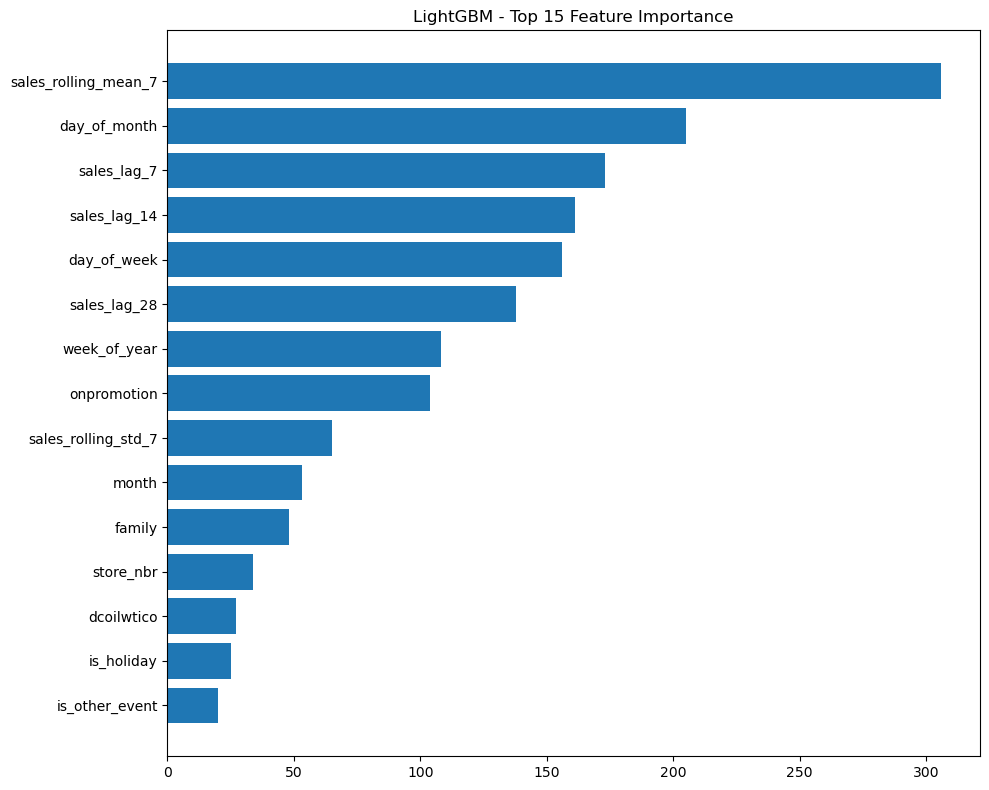

In [ ]:
lgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(lgb_importance["feature"][:15], lgb_importance["importance"][:15])
plt.gca().invert_yaxis()
plt.title("LightGBM - Top 15 Feature Importance")
plt.tight_layout()
plt.show()

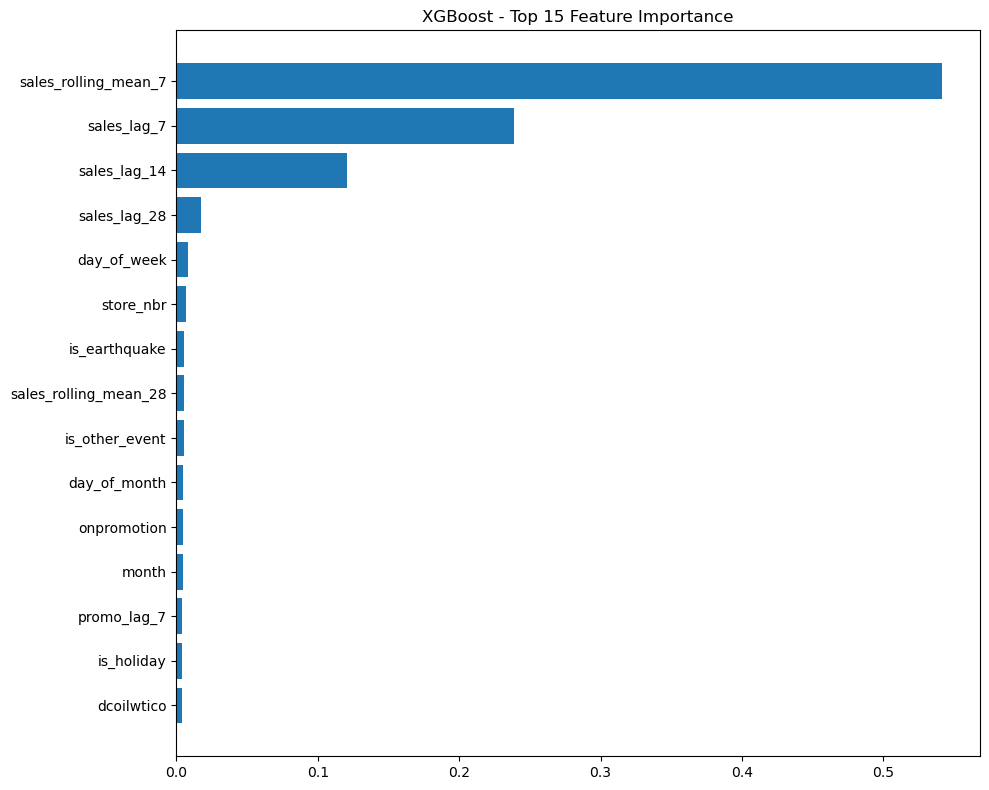

In [41]:
xgb_importance = pd.DataFrame({
    "feature": xgb_feature_order,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(xgb_importance["feature"][:15], xgb_importance["importance"][:15])
plt.gca().invert_yaxis()
plt.title("XGBoost - Top 15 Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
best_params = study.best_trials[0].params

best_lgb = lgb.LGBMRegressor(n_estimators=1000, **best_params, random_state=42)
best_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])


Try CatBoost model

In [16]:
from catboost import CatBoostRegressor

cat_cols = ["family", "city", "state", "type"]
cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, random_seed=42)
cat_model.fit(X_train, y_train,cat_features=cat_cols, eval_set=(X_val, y_val), early_stopping_rounds=50)


0:	learn: 1052.9256408	test: 1189.5840641	best: 1189.5840641 (0)	total: 351ms	remaining: 5m 50s
1:	learn: 1007.7711656	test: 1132.9569914	best: 1132.9569914 (1)	total: 619ms	remaining: 5m 8s
2:	learn: 965.1015335	test: 1078.5409379	best: 1078.5409379 (2)	total: 848ms	remaining: 4m 41s
3:	learn: 924.5953411	test: 1026.6787222	best: 1026.6787222 (3)	total: 1.09s	remaining: 4m 32s
4:	learn: 886.1681926	test: 979.2556734	best: 979.2556734 (4)	total: 1.3s	remaining: 4m 19s
5:	learn: 849.7438733	test: 933.8789118	best: 933.8789118 (5)	total: 1.52s	remaining: 4m 11s
6:	learn: 815.2300939	test: 890.3936664	best: 890.3936664 (6)	total: 1.72s	remaining: 4m 3s
7:	learn: 782.7012291	test: 849.4367920	best: 849.4367920 (7)	total: 1.94s	remaining: 4m 1s
8:	learn: 751.8623461	test: 810.5204930	best: 810.5204930 (8)	total: 2.17s	remaining: 3m 58s
9:	learn: 722.8702202	test: 773.5188112	best: 773.5188112 (9)	total: 2.38s	remaining: 3m 55s
10:	learn: 695.4598826	test: 738.4475570	best: 738.4475570 (10)	

CatBoostRegressor(iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42)

Tune with optuna

In [17]:
def objective_cat(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_seed": 42,
        "verbose": False
    }

    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train,
        cat_features=cat_cols,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )

    pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, pred))

study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=20)

print("Best RMSE:", study_cat.best_value)
print("Best params:", study_cat.best_params)


[I 2026-03-14 19:59:45,759] A new study created in memory with name: no-name-a8ab18e6-fd2f-4b73-b43e-927904611a8f
[I 2026-03-14 20:00:31,241] Trial 0 finished with value: 251.5017353673448 and parameters: {'learning_rate': 0.043708610696262626, 'depth': 10, 'l2_leaf_reg': 7.587945476302646, 'bagging_temperature': 0.5986584841970366, 'border_count': 66}. Best is trial 0 with value: 251.5017353673448.
[I 2026-03-14 20:01:05,931] Trial 1 finished with value: 239.72040278491872 and parameters: {'learning_rate': 0.02403950683025824, 'depth': 4, 'l2_leaf_reg': 8.795585311974417, 'bagging_temperature': 0.6011150117432088, 'border_count': 190}. Best is trial 1 with value: 239.72040278491872.
[I 2026-03-14 20:03:00,408] Trial 2 finished with value: 250.46944480508003 and parameters: {'learning_rate': 0.011852604486622221, 'depth': 10, 'l2_leaf_reg': 8.491983767203795, 'bagging_temperature': 0.21233911067827616, 'border_count': 72}. Best is trial 1 with value: 239.72040278491872.
[I 2026-03-14 2

Best RMSE: 226.1500698850906
Best params: {'learning_rate': 0.08570119338032246, 'depth': 9, 'l2_leaf_reg': 2.9372548765150177, 'bagging_temperature': 0.0863689218192708, 'border_count': 204}


In [18]:
best_cat = CatBoostRegressor(**study_cat.best_params, iterations=1000, random_seed=42, verbose=100)
best_cat.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_val, y_val), early_stopping_rounds=50)


0:	learn: 1017.0736233	test: 1144.5444072	best: 1144.5444072 (0)	total: 378ms	remaining: 6m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 226.1500701
bestIteration = 32

Shrink model to first 33 iterations.


CatBoostRegressor(bagging_temperature=0.0863689218192708, border_count=204, depth=9, iterations=1000, l2_leaf_reg=2.9372548765150177, learning_rate=0.08570119338032246, loss_function='RMSE', random_seed=42, verbose=100)